# Phase 4 — RFM Segmentation
## Retail Customer Analysis — UCI Online Retail II

**Goal of this phase:** divide the customer base into actionable segments using **RFM analysis**,
which scores every customer on three behaviours:

- **Recency (R)** — how recently they last purchased (more recent is better).
- **Frequency (F)** — how often they purchase (more orders is better).
- **Monetary (M)** — how much they spend in total (more is better).

We first score each customer **1&ndash;5** on each dimension (quintiles), which is the rigorous,
reproducible foundation. We then layer **named business segments** (Champions, Loyal, At Risk,
Lost, etc.) on top, so the results are immediately readable for non-technical stakeholders.

**Data source:** `customers_clean` from PostgreSQL (5,852 identifiable customers).


## 1. Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass
import os
from pathlib import Path
from sqlalchemy import create_engine

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT   = find_project_root()
PROCESSED_PATH = str(PROJECT_ROOT / 'data' / 'processed') + os.sep
os.makedirs(PROCESSED_PATH, exist_ok=True)

## 2. Load Data from PostgreSQL

We need one row per transaction with the customer, the order (invoice), the date, and the
revenue, so we can roll these up into per-customer RFM metrics.

In [2]:
username = getpass.getuser()
engine = create_engine(f'postgresql+psycopg2://{username}@localhost:5432/retail_db', future=True)

df = pd.read_sql('SELECT customer_id, invoice, invoicedate, revenue FROM customers_clean', engine)
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print(f'Loaded {len(df):,} rows for {df["customer_id"].nunique():,} customers')
df.head(3)

Loaded 776,579 rows for 5,852 customers


,customer_id,invoice,invoicedate,revenue
0,13085,489434,2009-12-01 07:45:00,83.40
1,13085,489434,2009-12-01 07:45:00,81.00
2,13085,489434,2009-12-01 07:45:00,81.00


## 3. Set the Snapshot Date

Recency is measured relative to a fixed reference point. We use the day **after** the last
transaction in the dataset, as if we were running this analysis the morning after the data
ends. This makes every customer's recency comparable.

In [3]:
# Reference date = one day after the most recent transaction
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)
print('Last transaction:', df['invoicedate'].max())
print('Snapshot date   :', snapshot_date)

Last transaction: 2011-12-09 12:50:00
Snapshot date   : 2011-12-10 12:50:00


## 4. Compute RFM Metrics per Customer

We collapse the transaction history down to one row per customer:
- **Recency** = days between their last purchase and the snapshot date.
- **Frequency** = number of distinct orders (invoices) they placed.
- **Monetary** = total revenue across all their orders.

In [4]:
# Group by customer and compute the three RFM metrics in one pass
rfm = df.groupby('customer_id').agg(
    recency=('invoicedate', lambda x: (snapshot_date - x.max()).days),
    frequency=('invoice', 'nunique'),      # distinct orders, not line items
    monetary=('revenue', 'sum')
).reset_index()

print(f'RFM table: {len(rfm):,} customers')
rfm.head()

RFM table: 5,852 customers


,customer_id,recency,frequency,monetary
0,12346,326,3,"77,352.96"
1,12347,2,8,"4,921.53"
2,12348,75,5,"1,658.40"
3,12349,19,3,"3,678.69"
4,12350,310,1,294.40


In [5]:
# Quick look at the distributions — note the heavy skew typical of retail
rfm[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,"5,852.00","5,852.00","5,852.00"
mean,200.20,6.25,"2,916.71"
std,208.51,12.75,"14,306.87"
min,1.00,1.00,2.95
25%,25.00,1.00,339.57
50%,95.00,3.00,856.02
75%,379.00,7.00,"2,241.03"
max,739.00,373.00,"580,987.04"


## 5. Score Each Customer 1&ndash;5 (Quintiles)

Each metric is split into five equal-sized groups (quintiles) and scored 1&ndash;5.

A subtle but important point: many customers share the same frequency (e.g. lots of one-time
buyers with frequency = 1), which would break a naive quintile split. We therefore rank the
values first (`rank(method='first')`) so ties are broken and the five groups stay equal-sized.

Direction matters: for **Recency, lower is better**, so the most-recent customers get a 5.
For **Frequency and Monetary, higher is better**, so the biggest buyers get a 5.

In [6]:
# Recency: lower days = more recent = better -> reverse the labels so low recency scores 5
rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'),
                         5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: higher = better -> high frequency scores 5
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                         5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: higher = better -> high spend scores 5
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                         5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM score (concatenated) and a simple summed score for ranking
rfm['RFM_cell'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_sum']  = rfm[['R_score', 'F_score', 'M_score']].sum(axis=1)

rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_cell,RFM_sum
0,12346,326,3,"77,352.96",2,3,5,235,10
1,12347,2,8,"4,921.53",5,4,5,545,14
2,12348,75,5,"1,658.40",3,4,4,344,11
3,12349,19,3,"3,678.69",5,3,5,535,13
4,12350,310,1,294.40,2,1,2,212,5


## 6. Assign Named Segments

We translate the scores into recognisable business segments using a standard mapping based on
**Recency and Frequency** (the two dimensions that best describe the customer relationship;
Monetary is captured separately in the scores). The map covers all 25 possible R&times;F
combinations, so every customer lands in exactly one segment.

In [7]:
# Standard RFM segment map, keyed on the two-digit Recency+Frequency score.
# Patterns are anchored so each 2-digit cell matches exactly one segment.
segment_map = {
    r'^[1-2][1-2]$': 'Hibernating',
    r'^[1-2][3-4]$': 'At Risk',
    r'^[1-2]5$':     'Cannot Lose Them',
    r'^3[1-2]$':     'About to Sleep',
    r'^33$':         'Need Attention',
    r'^[3-4][4-5]$': 'Loyal Customers',
    r'^41$':         'Promising',
    r'^51$':         'New Customers',
    r'^[4-5][2-3]$': 'Potential Loyalists',
    r'^5[4-5]$':     'Champions',
}

# Build the two-digit R+F key, then map it to a named segment
rfm['segment'] = (rfm['R_score'].astype(str) + rfm['F_score'].astype(str))
rfm['segment'] = rfm['segment'].replace(segment_map, regex=True)

# Confirm every customer was assigned a real segment (no leftover digit codes)
unmapped = rfm.loc[rfm['segment'].str.fullmatch(r'\d{2}'), 'segment'].unique()
print('Unmapped score codes (should be empty):', list(unmapped))
print('\nSegments assigned:')
print(rfm['segment'].value_counts())

Unmapped score codes (should be empty): []

Segments assigned:
segment
Hibernating            1511
Loyal Customers        1157
Champions               825
At Risk                 758
Potential Loyalists     709
About to Sleep          382
Need Attention          269
Promising               114
Cannot Lose Them         72
New Customers            55
Name: count, dtype: int64


## 7. Segment Summary

The key business table: how many customers each segment holds, their average RFM profile, and
how much revenue they represent. This is what makes RFM actionable &mdash; it shows where the
value is concentrated and which groups to prioritise.

In [8]:
# Build a per-segment summary with size, average behaviour, and revenue share
segment_summary = rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(1)

# Add percentage shares for customers and revenue
segment_summary['pct_customers'] = (segment_summary['customers'] / len(rfm) * 100).round(1)
segment_summary['pct_revenue']   = (segment_summary['total_revenue'] /
                                    segment_summary['total_revenue'].sum() * 100).round(1)

# Sort by revenue contribution — most valuable segments first
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)
segment_summary

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_customers,pct_revenue
segment,,,,,,,
Champions,825,8.50,19.30,"10,614.90","8,757,252.40",14.10,51.30
Loyal Customers,1157,66.10,9.80,"4,049.20","4,684,912.20",19.80,27.40
At Risk,758,371.40,3.90,"1,440.80","1,092,094.20",13.00,6.40
Potential Loyalists,709,25.40,2.60,"1,144.50","811,453.50",12.10,4.80
Hibernating,1511,456.40,1.20,410.70,"620,553.60",25.80,3.60
Cannot Lose Them,72,327.20,16.40,"6,991.70","503,405.10",1.20,2.90
Need Attention,269,112.00,3.10,"1,259.10","338,698.60",4.60,2.00
About to Sleep,382,105.50,1.40,526.80,"201,225.80",6.50,1.20
Promising,114,38.70,1.00,349.50,"39,847.40",1.90,0.20


## 8. Visualise the Segments

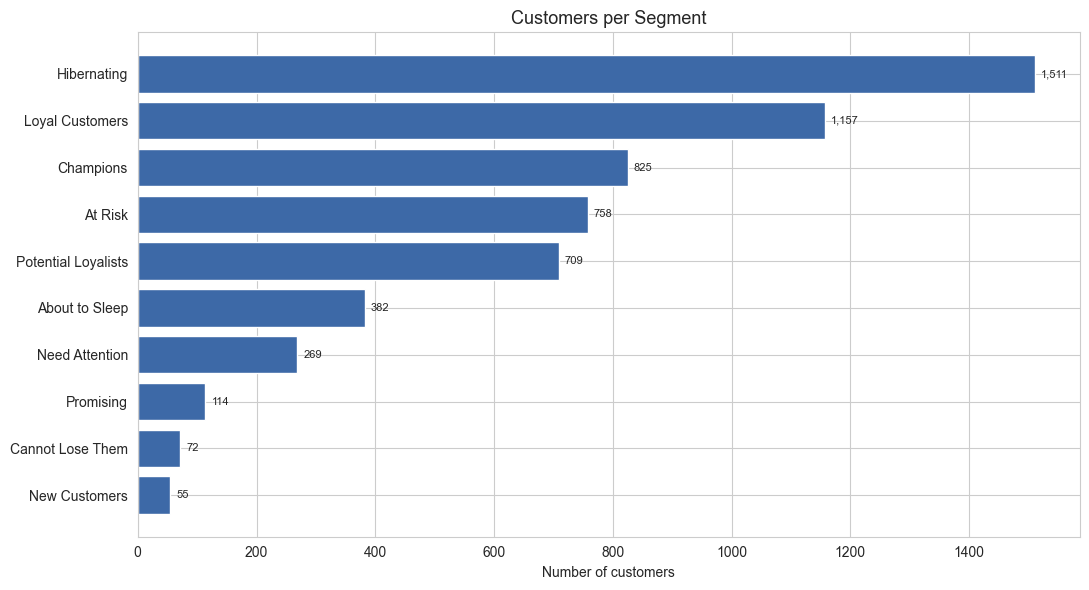

In [9]:
# Customers per segment
seg_counts = rfm['segment'].value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(seg_counts.index[::-1], seg_counts.values[::-1], color="#3d69a7")
ax.set_title('Customers per Segment', fontsize=13)
ax.set_xlabel('Number of customers')
for i, v in enumerate(seg_counts.values[::-1]):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

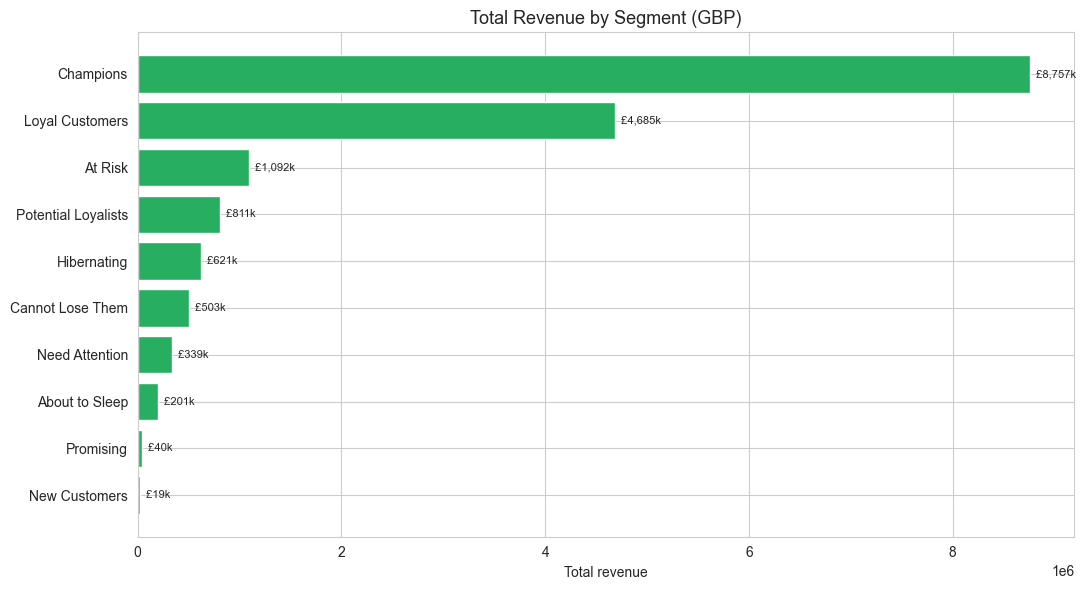

In [10]:
# Revenue share by segment — where the money actually comes from
seg_rev = segment_summary['total_revenue'].sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(seg_rev.index, seg_rev.values, color='#27ae60')
ax.set_title('Total Revenue by Segment (GBP)', fontsize=13)
ax.set_xlabel('Total revenue')
for i, v in enumerate(seg_rev.values):
    ax.text(v, i, f'  £{v/1000:,.0f}k', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Save Results

Save the customer-level RFM table to CSV and load it into PostgreSQL as `rfm_segments`, so it
is available for the Tableau dashboard in a later phase.

In [11]:
# CSV backup for Tableau
rfm.to_csv(PROCESSED_PATH + 'rfm_segments.csv', index=False)

# Load into PostgreSQL alongside the cleaned tables
rfm.to_sql('rfm_segments', engine, if_exists='replace', index=False,
           chunksize=5000, method='multi')
print(f'Saved and loaded rfm_segments: {len(rfm):,} customers')

Saved and loaded rfm_segments: 5,852 customers


## 10. Phase 4 Summary

Every customer now carries an R, F and M score (1&ndash;5) and a named segment, with a summary
showing where customers and revenue concentrate. This is the practical bridge between raw
behaviour and targeted action.

**Next — Phase 5: Customer Lifetime Value (CLV).** We use the BG/NBD and Gamma-Gamma
probabilistic models to predict each customer's future purchases and expected value, building
directly on the RFM behaviour captured here.
